# TIKTOK CREATORS DATA AUDIT, CLEANING, VISUALIZATION & SAMPLING FRAME

Notebook này viết lại theo skeleton code ban đầu, nhưng hoàn chỉnh hơn theo hướng:
- Kết nối MongoDB và tải dữ liệu
- Kiểm tra chất lượng dữ liệu thô
- Làm sạch, chuẩn hóa kiểu dữ liệu
- Trực quan hóa phân phối chính
- Thống kê phục vụ thiết kế sampling cho đề tài  
  **Clustering Vietnamese TikTok Creators: A Comparative Analysis of Unsupervised Machine Learning Models on Multidimensional Data**

> Ghi chú: notebook này **không xóa dữ liệu thô ngay lập tức**. Thay vào đó, nó tạo thêm các cột chuẩn hóa, cờ kiểm tra chất lượng, và bảng sampling frame để bạn dùng cho bước clustering sau.

## BƯỚC 1. Cài đặt và import thư viện

In [1]:
# ==========================================
# TIKTOK CREATORS DATA AUDIT & SAMPLING FRAME
# Phase GĐ1: Audit / Cleaning / Sampling Design
# ==========================================

import os
import re
import math
import warnings
from collections import Counter

import pymongo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("✓ Libraries loaded")

✓ Libraries loaded


## BƯỚC 2. Kết nối MongoDB

In [2]:
# Cấu hình kết nối
MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017")
DB_NAME = os.getenv("MONGO_DB_NAME", "tiktok_ads_db")
COLLECTION_NAME = os.getenv("MONGO_COLLECTION_NAME", "sample_direction1_category_stratified")

# Kết nối
try:
    client = pymongo.MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    client.admin.command("ping")
    db = client[DB_NAME]
    collection = db[COLLECTION_NAME]

    doc_count = collection.count_documents({})
    print(f"✓ Kết nối thành công")
    print(f"✓ Database  : {DB_NAME}")
    print(f"✓ Collection: {COLLECTION_NAME}")
    print(f"✓ Documents : {doc_count:,}")
except Exception as e:
    raise RuntimeError(f"Lỗi kết nối MongoDB: {e}")

✓ Kết nối thành công
✓ Database  : tiktok_ads_db
✓ Collection: sample_direction1_category_stratified
✓ Documents : 3,000


## BƯỚC 3. Tải dữ liệu từ MongoDB

In [3]:
# Chọn các trường (cột) cần lấy
fields_to_get = {
    '_id': 1,
    'creator_id': 1,
    'name': 1,
    'country': 1,
    'followers': 1,
    'engagement': 1,
    'median_views': 1,
    'price': 1,
    'broadcast_score': 1,
    'collab_score': 1,
    'category': 1
}

docs = list(collection.find({}, fields_to_get))
df = pd.DataFrame(docs)

# Đổi tên cột về snake_case để xử lý ổn định hơn
rename_map = {
    '_id': '_id',
    'creator_id': 'creator_id',
    'name': 'name',
    'country': 'country',
    'followers': 'followers',
    'engagement': 'engagement',
    'median_views': 'median_views',
    'price': 'price',
    'broadcast_score': 'broadcast_score',
    'collab_score': 'collab_score',
    'category': 'category'
}
df = df.rename(columns=rename_map)

print(f"Shape dữ liệu gốc: {df.shape}")
display(df.head(3))

Shape dữ liệu gốc: (3000, 11)


,_id,broadcast_score,collab_score,country,engagement,followers,creator_id,median_views,name,price,category
0,congoctuongso,N/A,71.9,Unknown,2.91%,602.7K,congoctuongso,23.8K,Cô Ngọc Tướng Số,"50,000,000 VND",Talent Showcase
1,namdireview,91.6,77.1,Unknown,2.85%,412.7K,namdireview,14.8K,Nam Đi Review.,"10,000,000 VND","Other Beauty & Personal Care, Beauty & Personal Care, Tech Products & Tests, Appliances, Tech & Electronics"
2,maxpxt,N/A,73.8,Unknown,3.39%,433.6K,maxpxt,1.1K,Max (maxpxt),"1,300,000 VND",Non-video Games


## BƯỚC 4. Làm sạch và chuẩn hóa dữ liệu

Các cột sau sẽ được chuẩn hóa:
- `followers` → `followers_num`
- `engagement` → `engagement_num`
- `median_views` → `median_views_num`
- `price` → `price_num`

Ngoài ra tạo thêm:
- cờ missing
- cờ outlier thô
- các cột `log1p` cho biến scale lớn

In [4]:
print("Đang làm sạch dữ liệu...\n")

def parse_compact_number(value):
    '''
    Chuyển các dạng:
    - 1,5M / 1.5M -> 1500000
    - 500K -> 500000
    - 1200 -> 1200
    - None / '' -> np.nan
    '''
    if pd.isna(value):
        return np.nan

    s = str(value).strip().upper()
    if s == "":
        return np.nan

    # chuẩn hóa dấu phẩy/chấm thập phân
    s = s.replace(" ", "").replace(",", ".")

    multiplier = 1
    if s.endswith("M"):
        multiplier = 1_000_000
        s = s[:-1]
    elif s.endswith("K"):
        multiplier = 1_000
        s = s[:-1]
    elif s.endswith("B"):
        multiplier = 1_000_000_000
        s = s[:-1]

    # chỉ giữ ký tự số, dấu chấm, dấu âm
    s = re.sub(r"[^0-9.\-]", "", s)

    try:
        return float(s) * multiplier
    except:
        return np.nan


def parse_percent(value):
    '''
    Chuyển:
    - 14,06% -> 14.06
    - 5.2%   -> 5.2
    '''
    if pd.isna(value):
        return np.nan

    s = str(value).strip().replace("%", "").replace(",", ".")
    s = re.sub(r"[^0-9.\-]", "", s)

    try:
        return float(s)
    except:
        return np.nan


def parse_price_vnd(value):
    '''
    Chuyển:
    - 12.801.218 VND -> 12801218
    - 5,000,000 VND  -> 5000000
    - Thỏa thuận / Chưa đặt -> np.nan
    '''
    if pd.isna(value):
        return np.nan

    s = str(value).strip()
    if s == "":
        return np.nan

    lowered = s.lower()
    invalid_terms = ["thỏa thuận", "thoả thuận", "chưa đặt", "liên hệ", "contact", "deal"]
    if any(term in lowered for term in invalid_terms):
        return np.nan

    # giữ duy nhất chữ số
    s_digits = re.sub(r"[^0-9]", "", s)
    if s_digits == "":
        return np.nan

    try:
        return float(s_digits)
    except:
        return np.nan


def normalize_categories(value):
    '''
    Chuẩn hóa cột category về list[str]
    '''
    if pd.isna(value):
        return []

    if isinstance(value, list):
        cleaned = []
        for item in value:
            if pd.isna(item):
                continue
            item = str(item).strip()
            if item:
                cleaned.append(item)
        return list(dict.fromkeys(cleaned))

    if isinstance(value, str):
        parts = [x.strip() for x in value.split(",") if x.strip()]
        return list(dict.fromkeys(parts))

    return []


# Chuẩn hóa numeric
df['followers_num'] = df['followers'].apply(parse_compact_number)
df['engagement_num'] = df['engagement'].apply(parse_percent)
df['median_views_num'] = df['median_views'].apply(parse_compact_number)
df['price_num'] = df['price'].apply(parse_price_vnd)

# Chuẩn hóa score
df['broadcast_score_num'] = pd.to_numeric(df['broadcast_score'], errors='coerce')
df['collab_score_num'] = pd.to_numeric(df['collab_score'], errors='coerce')

# Chuẩn hóa category
df['category_list'] = df['category'].apply(normalize_categories)
df['n_categories'] = df['category_list'].apply(len)

# Cờ missing
for col in ['followers_num', 'engagement_num', 'median_views_num', 'price_num',
            'broadcast_score_num', 'collab_score_num']:
    df[f'{col}_missing'] = df[col].isna().astype(int)

# Log transform cho các biến scale lớn
for col in ['followers_num', 'median_views_num', 'price_num']:
    df[f'{col}_log1p'] = np.log1p(df[col])

print("✓ Đã chuẩn hóa xong")
display(df[['name', 'followers', 'followers_num', 'engagement', 'engagement_num',
            'median_views', 'median_views_num', 'price', 'price_num', 'n_categories']].head())

Đang làm sạch dữ liệu...

✓ Đã chuẩn hóa xong


,name,followers,followers_num,engagement,engagement_num,median_views,median_views_num,price,price_num,n_categories
0,Cô Ngọc Tướng Số,602.7K,602700.0,2.91%,2.91,23.8K,23800.0,"50,000,000 VND",50000000.0,1
1,Nam Đi Review.,412.7K,412700.0,2.85%,2.85,14.8K,14800.0,"10,000,000 VND",10000000.0,5
2,Max (maxpxt),433.6K,433600.0,3.39%,3.39,1.1K,1100.0,"1,300,000 VND",1300000.0,1
3,Hiển Ở Nhà,836.7K,836700.0,2.21%,2.21,469K,469000.0,"7,000,000 VND",7000000.0,5
4,Lê Trinh,2M,2000000.0,1.40%,1.40,12.5K,12500.0,"58,297,000 VND",58297000.0,5


## BƯỚC 4. Audit dữ liệu thô trước khi làm sạch

In [5]:
print("=== THÔNG TIN TỔNG QUAN ===")
print(df.info())

print("\n=== TỶ LỆ MISSING THEO CỘT ===")
missing_ratio = (
    df.isna()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .rename("missing_pct")
      .to_frame()
)
display(missing_ratio)

print("=== DUPLICATE CHECK ===")
dup_creator_id = df.duplicated(subset=['creator_id']).sum() if 'creator_id' in df.columns else None
dup_name = df.duplicated(subset=['name']).sum() if 'name' in df.columns else None
print(f"Duplicate theo creator_id: {dup_creator_id:,}" if dup_creator_id is not None else "Không có cột creator_id")
print(f"Duplicate theo name      : {dup_name:,}" if dup_name is not None else "Không có cột name")

=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   _id                          3000 non-null   object 
 1   broadcast_score              3000 non-null   object 
 2   collab_score                 3000 non-null   object 
 3   country                      3000 non-null   object 
 4   engagement                   3000 non-null   object 
 5   followers                    3000 non-null   object 
 6   creator_id                   3000 non-null   object 
 7   median_views                 3000 non-null   object 
 8   name                         3000 non-null   object 
 9   price                        3000 non-null   object 
 10  category                     3000 non-null   object 
 11  followers_num                3000 non-null   float64
 12  engagement_num               3000 non-null   flo

,missing_pct
broadcast_score_num,61.10
collab_score_num,1.53
_id,0.00
broadcast_score,0.00
median_views_num_log1p,0.00
followers_num_log1p,0.00
collab_score_num_missing,0.00
broadcast_score_num_missing,0.00
price_num_missing,0.00
median_views_num_missing,0.00


=== DUPLICATE CHECK ===
Duplicate theo creator_id: 0
Duplicate theo name      : 7


## BƯỚC 6. Kiểm tra tính hợp lệ sau khi chuẩn hóa

In [6]:
validation_summary = pd.DataFrame({
    "non_null": df.notna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})

display(validation_summary.loc[
    ['creator_id', 'name', 'country', 'followers_num', 'engagement_num', 'median_views_num',
     'price_num', 'broadcast_score_num', 'collab_score_num', 'n_categories']
])

print("=== KIỂM TRA BIÊN GIÁ TRỊ ===")
checks = {
    "followers_num < 0": (df['followers_num'] < 0).sum(),
    "engagement_num < 0": (df['engagement_num'] < 0).sum(),
    "engagement_num > 100": (df['engagement_num'] > 100).sum(),
    "median_views_num < 0": (df['median_views_num'] < 0).sum(),
    "price_num < 0": (df['price_num'] < 0).sum(),
    "n_categories == 0": (df['n_categories'] == 0).sum(),
}
for k, v in checks.items():
    print(f"{k:25s}: {v:,}")

,non_null,missing_pct
creator_id,3000,0.00
name,3000,0.00
country,3000,0.00
followers_num,3000,0.00
engagement_num,3000,0.00
median_views_num,3000,0.00
price_num,3000,0.00
broadcast_score_num,1167,61.10
collab_score_num,2954,1.53
n_categories,3000,0.00


=== KIỂM TRA BIÊN GIÁ TRỊ ===
followers_num < 0        : 0
engagement_num < 0       : 0
engagement_num > 100     : 0
median_views_num < 0     : 0
price_num < 0            : 0
n_categories == 0        : 35


## BƯỚC 7. Thống kê mô tả cho các cột số chính

In [7]:
numeric_cols = [
    'followers_num', 'engagement_num', 'median_views_num', 'price_num',
    'broadcast_score_num', 'collab_score_num', 'n_categories'
]

desc = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc['missing_pct'] = (df[numeric_cols].isna().mean() * 100).round(2)
display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct
followers_num,3000.0,4.216419e+05,1.100560e+06,3200.00,9800.000,17400.0000,57975.00,148850.000,340300.00,1.600000e+06,4.201000e+06,2.120000e+07,0.00
engagement_num,3000.0,5.378610e+00,4.957742e+00,0.12,0.450,1.0195,2.38,3.975,6.98,1.363050e+01,1.986260e+01,9.416000e+01,0.00
median_views_num,3000.0,9.615286e+04,4.583041e+05,11.00,597.940,2095.0000,9800.00,29450.000,80900.00,3.664150e+05,1.100000e+06,2.290000e+07,0.00
price_num,3000.0,1.339879e+07,1.113226e+08,1.00,10000.000,100000.0000,916500.00,2000000.000,5000000.00,2.500000e+07,1.200810e+08,2.631000e+09,0.00
broadcast_score_num,1167.0,9.375981e+01,2.618424e+00,90.10,90.200,90.2000,91.60,93.200,95.80,9.860000e+01,9.940000e+01,1.000000e+02,61.10
collab_score_num,2954.0,7.837986e+01,5.903956e+00,61.20,68.153,70.6650,74.50,77.200,80.60,9.060000e+01,9.440000e+01,9.880000e+01,1.53
n_categories,3000.0,2.433667e+00,1.570485e+00,0.00,0.000,1.0000,1.00,2.000,3.00,6.000000e+00,7.000000e+00,8.000000e+00,0.00


## BƯỚC 8. Đánh dấu outlier thô bằng IQR

Ở bước này chỉ **đánh dấu** outlier, chưa xóa luôn.  
Mục tiêu là để bạn kiểm tra trước khi quyết định sampling / clustering.

In [8]:
def iqr_flags(series):
    s = series.dropna()
    if len(s) == 0:
        return pd.Series([False] * len(series), index=series.index)

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

for col in ['followers_num', 'engagement_num', 'median_views_num', 'price_num']:
    df[f'{col}_outlier_iqr'] = iqr_flags(df[col])

outlier_summary = pd.Series({
    col: int(df[f'{col}_outlier_iqr'].sum())
    for col in ['followers_num', 'engagement_num', 'median_views_num', 'price_num']
}).rename('n_outliers').to_frame()

display(outlier_summary)

,n_outliers
followers_num,362
engagement_num,143
median_views_num,335
price_num,319


## BƯỚC 9. Phân loại creators theo mức giá

In [9]:
price_non_null = df['price_num'].dropna()

price_33 = price_non_null.quantile(0.33) if len(price_non_null) else np.nan
price_67 = price_non_null.quantile(0.67) if len(price_non_null) else np.nan

print(f"Ngưỡng 33%: {price_33:,.0f} VND" if pd.notna(price_33) else "Ngưỡng 33%: NaN")
print(f"Ngưỡng 67%: {price_67:,.0f} VND" if pd.notna(price_67) else "Ngưỡng 67%: NaN")
print()

def classify_price(price):
    if pd.isna(price):
        return 'missing'
    if price < price_33:
        return 'low'
    elif price < price_67:
        return 'mid'
    return 'high'

df['price_tier'] = df['price_num'].apply(classify_price)

price_stats = df['price_tier'].value_counts(dropna=False)
print("Phân bổ theo mức giá:")
for tier, count in price_stats.items():
    percent = count / len(df) * 100
    print(f"  {tier.upper():8s}: {count:4,} creators ({percent:5.1f}%)")

Ngưỡng 33%: 1,000,000 VND
Ngưỡng 67%: 4,000,000 VND

Phân bổ theo mức giá:
  MID     : 1,223 creators ( 40.8%)
  HIGH    : 1,019 creators ( 34.0%)
  LOW     :  758 creators ( 25.3%)


## BƯỚC 10. Phân loại creators theo quy mô followers

In [10]:
print("Đang phân loại theo quy mô...\n")

MICRO_THRESHOLD = 500_000
MID_THRESHOLD = 2_000_000

print(f"Ngưỡng MICRO: < {MICRO_THRESHOLD:,} followers")
print(f"Ngưỡng MID  : {MICRO_THRESHOLD:,} - {MID_THRESHOLD:,} followers")
print(f"Ngưỡng MACRO: >= {MID_THRESHOLD:,} followers")

def classify_size(followers):
    if pd.isna(followers):
        return 'missing'
    if followers < MICRO_THRESHOLD:
        return 'micro'
    elif followers < MID_THRESHOLD:
        return 'mid'
    return 'macro'

df['size_tier'] = df['followers_num'].apply(classify_size)

size_stats = df['size_tier'].value_counts(dropna=False)
print("Phân bổ theo quy mô:")
for tier, count in size_stats.items():
    percent = count / len(df) * 100
    print(f"  {tier.upper():8s}: {count:4,} creators ({percent:5.1f}%)")

Đang phân loại theo quy mô...

Ngưỡng MICRO: < 500,000 followers
Ngưỡng MID  : 500,000 - 2,000,000 followers
Ngưỡng MACRO: >= 2,000,000 followers
Phân bổ theo quy mô:
  MICRO   : 2,457 creators ( 81.9%)
  MID     :  428 creators ( 14.3%)
  MACRO   :  115 creators (  3.8%)


## BƯỚC 11. Phân tích category / danh mục nội dung

In [11]:
print("Ví dụ dữ liệu category của 3 creators đầu tiên:\n")
for i in range(min(3, len(df))):
    name = df.iloc[i]['name']
    cats = df.iloc[i]['category_list']
    print(f"{i+1}. {name}")
    print(f"   Type: {type(cats)}")
    print(f"   Value: {cats}")
    print(f"   Số danh mục: {len(cats)}")
    print()

print("Phân tích theo danh mục nội dung...\n")

all_categories = []
for categories in df['category_list']:
    all_categories.extend(categories)

category_counter = Counter(all_categories)
top_20 = category_counter.most_common(20)

print("Top 20 danh mục phổ biến nhất:")
print("(Lưu ý: 1 creator có thể có nhiều danh mục)\n")

total_tags = sum(category_counter.values())
for i, (cat, count) in enumerate(top_20, 1):
    percent = count / total_tags * 100 if total_tags else 0
    print(f"{i:2d}. {count:4,} lượt ({percent:4.1f}%) - {cat}")

print(f"\nTổng số danh mục khác nhau: {len(category_counter):,}")
print(f"Tổng số lượt gắn tag      : {total_tags:,}")
print(f"Trung bình mỗi creator có : {total_tags/len(df):.1f} danh mục" if len(df) else "Không có dữ liệu")

Ví dụ dữ liệu category của 3 creators đầu tiên:

1. Cô Ngọc Tướng Số
   Type: <class 'list'>
   Value: ['Talent Showcase']
   Số danh mục: 1

2. Nam Đi Review.
   Type: <class 'list'>
   Value: ['Other Beauty & Personal Care', 'Beauty & Personal Care', 'Tech Products & Tests', 'Appliances', 'Tech & Electronics']
   Số danh mục: 5

3. Max (maxpxt)
   Type: <class 'list'>
   Value: ['Non-video Games']
   Số danh mục: 1

Phân tích theo danh mục nội dung...

Top 20 danh mục phổ biến nhất:
(Lưu ý: 1 creator có thể có nhiều danh mục)

 1.  471 lượt ( 6.5%) - Daily Life
 2.  433 lượt ( 5.9%) - Beauty Tutorials & Tips
 3.  426 lượt ( 5.8%) - Lip Syncing
 4.  361 lượt ( 4.9%) - Dance
 5.  308 lượt ( 4.2%) - Video Games
 6.  293 lượt ( 4.0%) - Beauty & Personal Care
 7.  257 lượt ( 3.5%) - Selfie
 8.  254 lượt ( 3.5%) - Outfits
 9.  251 lượt ( 3.4%) - News & Entertainment
10.  249 lượt ( 3.4%) - Music
11.  191 lượt ( 2.6%) - Comedy
12.  178 lượt ( 2.4%) - Family
13.  169 lượt ( 2.3%) - Movies & 

## BƯỚC 12. Gom category thành nhóm lớn để phục vụ sampling

Bạn có thể chỉnh mapping này sau. Mục tiêu hiện tại là tạo nhóm đủ ổn định cho stratified sampling.

In [12]:
CATEGORY_GROUP_MAP = {
    # Beauty & Fashion
    'Beauty Tutorials & Tips': 'Beauty & Fashion',
    'Beauty & Personal Care': 'Beauty & Fashion',
    'Selfie': 'Beauty & Fashion',
    'Outfits': 'Beauty & Fashion',
    'Apparel & Accessories': 'Beauty & Fashion',

    # Entertainment
    'Lip Syncing': 'Entertainment',
    'Dance': 'Entertainment',
    'Music': 'Entertainment',
    'Movies & TV': 'Entertainment',
    'Comedy': 'Entertainment',
    'Animation & Cosplay': 'Entertainment',
    'News & Entertainment': 'Entertainment',

    # Lifestyle
    'Daily Life': 'Lifestyle',
    'Family': 'Lifestyle',
    'Love & Romantic Relationships': 'Lifestyle',
    'Restaurant Exploration': 'Lifestyle',
    'Cooking & Recipes': 'Lifestyle',
    'Mukbang & Food Tasting': 'Lifestyle',

    # Knowledge / Tech / Gaming
    'Video Games': 'Knowledge / Tech',
    'Tech Products & Tests': 'Knowledge / Tech',
}

def map_category_groups(cat_list):
    groups = []
    for c in cat_list:
        groups.append(CATEGORY_GROUP_MAP.get(c, 'Others'))
    return list(dict.fromkeys(groups))

df['category_group_list'] = df['category_list'].apply(map_category_groups)
df['primary_category_group'] = df['category_group_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unlabeled')

group_counter = Counter(df['primary_category_group'])
group_stats = pd.DataFrame.from_dict(group_counter, orient='index', columns=['n_creators']).sort_values('n_creators', ascending=False)
group_stats['pct'] = (group_stats['n_creators'] / len(df) * 100).round(2)
display(group_stats)

,n_creators,pct
Others,904,30.13
Entertainment,808,26.93
Lifestyle,542,18.07
Beauty & Fashion,395,13.17
Knowledge / Tech,316,10.53
Unlabeled,35,1.17


## BƯỚC 13. Trực quan hóa phân phối số liệu chính

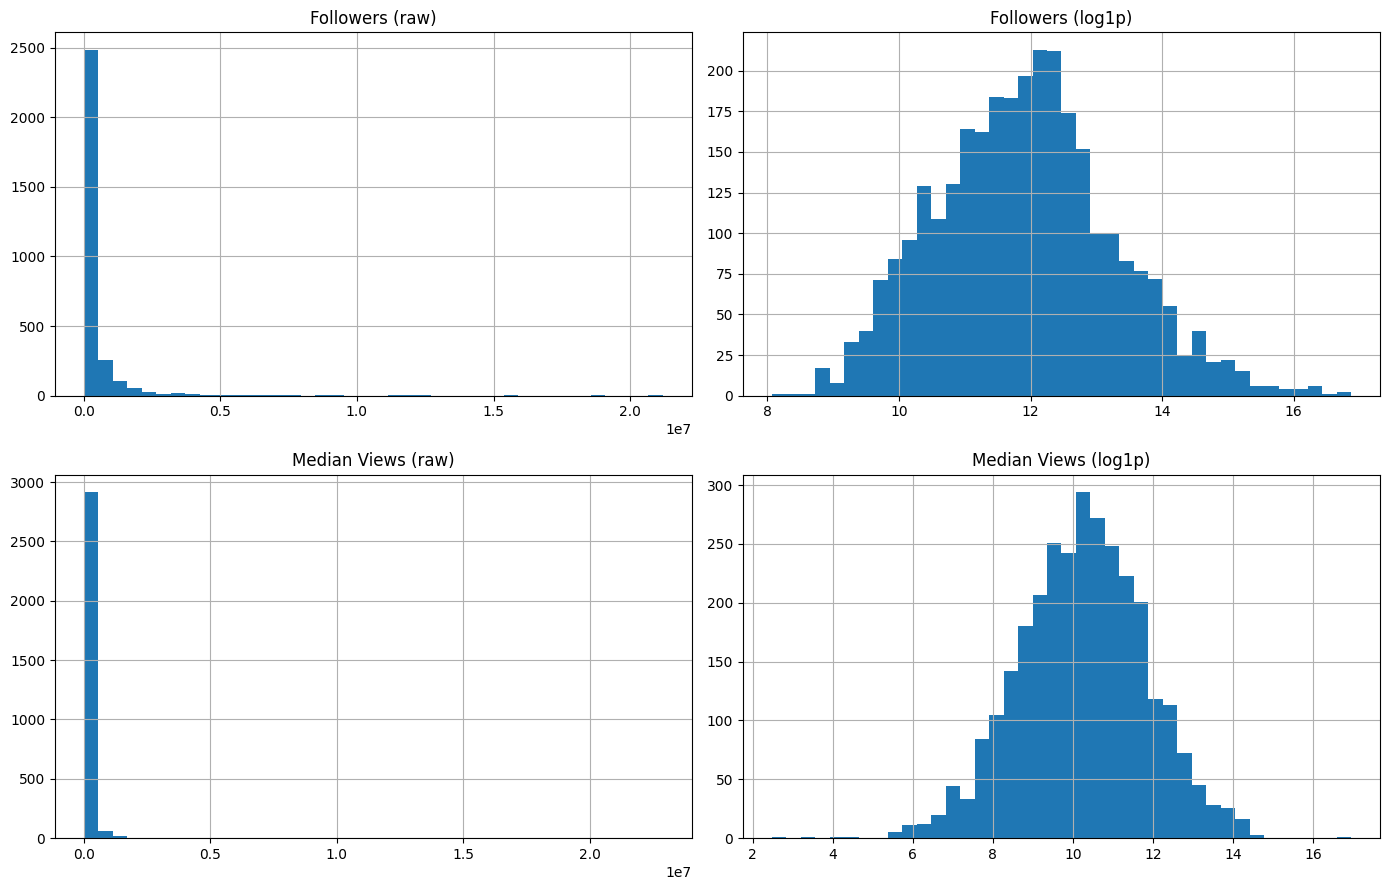

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

df['followers_num'].dropna().hist(ax=axes[0,0], bins=40)
axes[0,0].set_title('Followers (raw)')

df['followers_num_log1p'].dropna().hist(ax=axes[0,1], bins=40)
axes[0,1].set_title('Followers (log1p)')

df['median_views_num'].dropna().hist(ax=axes[1,0], bins=40)
axes[1,0].set_title('Median Views (raw)')

df['median_views_num_log1p'].dropna().hist(ax=axes[1,1], bins=40)
axes[1,1].set_title('Median Views (log1p)')

plt.tight_layout()
plt.show()

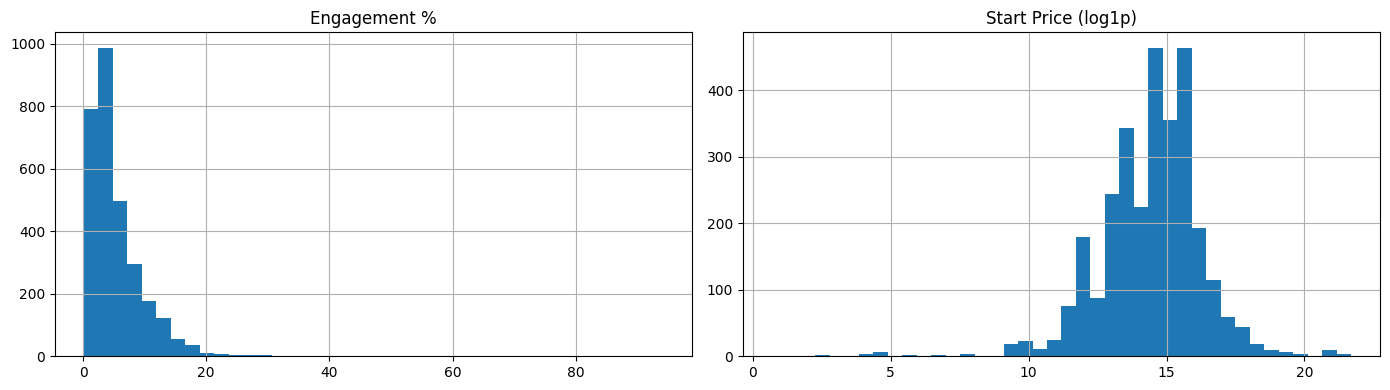

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['engagement_num'].dropna().hist(ax=axes[0], bins=40)
axes[0].set_title('Engagement %')

df['price_num_log1p'].dropna().hist(ax=axes[1], bins=40)
axes[1].set_title('Start Price (log1p)')

plt.tight_layout()
plt.show()

## BƯỚC 14. Trực quan hóa phân bổ quy mô, giá, và nhóm nội dung

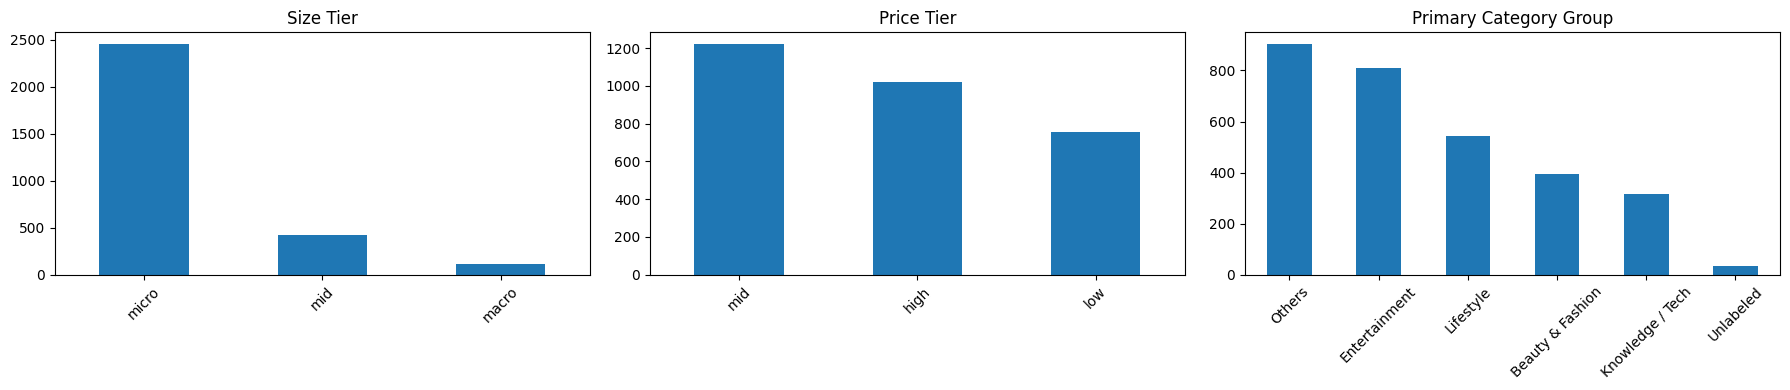

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df['size_tier'].value_counts().plot(kind='bar', ax=axes[0], title='Size Tier')
df['price_tier'].value_counts().plot(kind='bar', ax=axes[1], title='Price Tier')
df['primary_category_group'].value_counts().head(10).plot(kind='bar', ax=axes[2], title='Primary Category Group')

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## BƯỚC 15. Bảng chéo phục vụ thiết kế sampling

In [16]:
sampling_crosstab_1 = pd.crosstab(df['size_tier'], df['price_tier'], margins=True)
sampling_crosstab_2 = pd.crosstab(df['size_tier'], df['primary_category_group'], margins=True)

print("=== Cross-tab: size_tier × price_tier ===")
display(sampling_crosstab_1)

print("=== Cross-tab: size_tier × primary_category_group ===")
display(sampling_crosstab_2)

=== Cross-tab: size_tier × price_tier ===


price_tier,high,low,mid,All
size_tier,,,,
macro,104,6,5,115
micro,643,716,1098,2457
mid,272,36,120,428
All,1019,758,1223,3000


=== Cross-tab: size_tier × primary_category_group ===


primary_category_group,Beauty & Fashion,Entertainment,Knowledge / Tech,Lifestyle,Others,Unlabeled,All
size_tier,,,,,,,
macro,16,19,12,15,52,1,115
micro,327,714,243,444,701,28,2457
mid,52,75,61,83,151,6,428
All,395,808,316,542,904,35,3000


## BƯỚC 16. Tạo sampling frame

Sampling frame này chưa lấy mẫu ngay, mà tạo bảng nền để bạn:
- lọc dữ liệu usable
- biết mỗi creator thuộc stratum nào
- quyết định quota sampling sau

In [17]:
# Tiêu chí usable tối thiểu cho giai đoạn clustering cơ bản
df['is_usable_for_clustering'] = (
    df['followers_num'].notna() &
    df['engagement_num'].notna() &
    df['median_views_num'].notna()
)

# Stratum chính cho sampling
df['sampling_stratum'] = (
    df['size_tier'].astype(str) + " | " +
    df['price_tier'].astype(str) + " | " +
    df['primary_category_group'].astype(str)
)

sampling_frame = df[[
    'creator_id', 'name', 'country',
    'followers_num', 'engagement_num', 'median_views_num', 'price_num',
    'broadcast_score_num', 'collab_score_num',
    'n_categories', 'size_tier', 'price_tier',
    'primary_category_group', 'sampling_stratum',
    'is_usable_for_clustering'
]].copy()

display(sampling_frame.head())

print("=== USABLE RATE ===")
usable_rate = sampling_frame['is_usable_for_clustering'].mean() * 100
print(f"Tỷ lệ usable cho clustering: {usable_rate:.2f}%")

,creator_id,name,country,followers_num,engagement_num,median_views_num,price_num,broadcast_score_num,collab_score_num,n_categories,size_tier,price_tier,primary_category_group,sampling_stratum,is_usable_for_clustering
0,congoctuongso,Cô Ngọc Tướng Số,Unknown,602700.0,2.91,23800.0,50000000.0,NaN,71.9,1,mid,high,Others,mid | high | Others,True
1,namdireview,Nam Đi Review.,Unknown,412700.0,2.85,14800.0,10000000.0,91.6,77.1,5,micro,high,Others,micro | high | Others,True
2,maxpxt,Max (maxpxt),Unknown,433600.0,3.39,1100.0,1300000.0,NaN,73.8,1,micro,mid,Others,micro | mid | Others,True
3,hienonha,Hiển Ở Nhà,Unknown,836700.0,2.21,469000.0,7000000.0,NaN,88.6,5,mid,high,Others,mid | high | Others,True
4,trinhle1707,Lê Trinh,Unknown,2000000.0,1.40,12500.0,58297000.0,95.8,96.6,5,macro,high,Others,macro | high | Others,True


=== USABLE RATE ===
Tỷ lệ usable cho clustering: 100.00%


## BƯỚC 17. Gợi ý lấy mẫu cân bằng theo strata

Cell này **không bắt buộc chạy**. Nó là template để bạn sampling sau khi xem bảng phân bổ.

In [18]:
# # Ví dụ: lấy tối đa 100 creator mỗi stratum, chỉ từ các bản ghi usable
# MAX_PER_STRATUM = 100

# sampled_df = (
#     sampling_frame[sampling_frame['is_usable_for_clustering']]
#     .groupby('sampling_stratum', group_keys=False)
#     .apply(lambda x: x.sample(min(len(x), MAX_PER_STRATUM), random_state=42))
#     .reset_index(drop=True)
# )

# print(f"Tổng số creators sau sample demo: {len(sampled_df):,}")
# display(sampled_df.head())

## BƯỚC 18. Xuất file kết quả

Xuất:
- dữ liệu đã làm sạch
- sampling frame
- sample demo
- file head 100 dòng

In [19]:
# # head 100 để kiểm tra nhanh
# df.head(100).to_excel("tiktok_creators_head_100.xlsx", index=False)

# # dữ liệu đã chuẩn hóa
# df.to_csv("tiktok_creators_cleaned.csv", index=False, encoding="utf-8-sig")

# # sampling frame
# sampling_frame.to_csv("tiktok_creators_sampling_frame.csv", index=False, encoding="utf-8-sig")

# # sample demo
# sampled_df.to_csv("tiktok_creators_sample_demo.csv", index=False, encoding="utf-8-sig")

# print("✓ Đã xuất file:")
# print(" - tiktok_creators_head_100.xlsx")
# print(" - tiktok_creators_cleaned.csv")
# print(" - tiktok_creators_sampling_frame.csv")
# print(" - tiktok_creators_sample_demo.csv")

## BƯỚC 19. Kết luận nhanh để dùng cho đề tài

Sau notebook này, bạn đã có:
1. **Dataset đã chuẩn hóa kiểu dữ liệu**
2. **Audit về missing / duplicate / outlier thô**
3. **Phân phối theo size / price / category**
4. **Sampling frame đa chiều** để chuẩn bị cho:
   - stratified sampling
   - feature engineering
   - clustering bằng KMeans / GMM / HDBSCAN / v.v.

Bước tiếp theo hợp lý:
- quyết định rule loại bỏ bản ghi nhiễu
- chốt bộ feature cuối cho clustering
- tạo pipeline scale + PCA/UMAP + clustering


## BƯỚC 20. Chuẩn bị cho 2 hướng sampling 3000 IDs

Phần này triển khai **đúng 2 hướng** bạn yêu cầu, với các nguyên tắc chống bug:

- Luôn dùng `random_state=42` để đảm bảo **reproducibility**
- Kiểm tra **tên cột bắt buộc** trước khi sampling
- Chặn lỗi `ValueError` khi quota > số lượng hiện có trong từng nhóm
- Xử lý **rounding error** để tổng quota luôn đúng **3000**
- Tránh MultiIndex bằng `.reset_index(drop=True)`
- Có bước **redistribute quota thiếu** nếu một stratum không đủ số lượng để lấy

> Lưu ý: các cell dưới đây giả định rằng phần làm sạch trước đó đã chạy xong và `df` đã có các cột:
`creator_id`, `price_num`, `engagement_num`, `median_views_num`, `size_tier`, `primary_category_group`.


In [20]:

# ===== Kiểm tra cột bắt buộc trước khi sampling =====
REQUIRED_COLUMNS = [
    'creator_id',
    'price_num',
    'engagement_num',
    'median_views_num',
    'size_tier',
    'primary_category_group'
]

missing_required = [c for c in REQUIRED_COLUMNS if c not in df.columns]
if missing_required:
    raise KeyError(
        "Thiếu cột bắt buộc cho sampling: "
        + ", ".join(missing_required)
        + ". Hãy kiểm tra lại bước rename / cleaning phía trên."
    )

creator_id_dup = df['creator_id'].duplicated().sum()
print(f"Số creator_id bị trùng: {creator_id_dup:,}")

if creator_id_dup > 0:
    df_sampling_base = df.drop_duplicates(subset='creator_id').copy()
    print(f"Đã tạo df_sampling_base sau khi drop duplicate creator_id: {len(df_sampling_base):,} rows")
else:
    df_sampling_base = df.copy()
    print(f"df_sampling_base dùng trực tiếp từ df: {len(df_sampling_base):,} rows")

df_sampling_base['primary_category_group'] = (
    df_sampling_base['primary_category_group']
    .fillna('Unlabeled')
    .replace('', 'Unlabeled')
)

print("\nPhân phối size_tier:")
display(df_sampling_base['size_tier'].value_counts(dropna=False).to_frame('n'))

print("\nPhân phối primary_category_group:")
display(df_sampling_base['primary_category_group'].value_counts(dropna=False).to_frame('n'))


Số creator_id bị trùng: 0
df_sampling_base dùng trực tiếp từ df: 3,000 rows

Phân phối size_tier:


,n
size_tier,
micro,2457
mid,428
macro,115



Phân phối primary_category_group:


,n
primary_category_group,
Others,904
Entertainment,808
Lifestyle,542
Beauty & Fashion,395
Knowledge / Tech,316
Unlabeled,35



## BƯỚC 21. Helper functions chống bug cho proportional / stratified sampling

Cell này xử lý các lỗi phổ biến:

1. **Quota > population** trong một stratum  
2. **Tổng quota lệch khỏi 3000** do làm tròn  
3. **Thiếu quota** sau khi cap theo population  
4. **MultiIndex** sau `groupby().apply()`  


In [21]:

from typing import List

def largest_remainder_allocation(weights: pd.Series, total: int) -> pd.Series:
    '''
    Phân bổ tổng số lượng theo tỷ trọng bằng Largest Remainder Method.
    Đảm bảo tổng cuối cùng đúng bằng `total`.
    '''
    weights = weights.fillna(0).astype(float)
    if total < 0:
        raise ValueError("total phải >= 0")
    if weights.sum() <= 0:
        return pd.Series(0, index=weights.index, dtype=int)

    raw = weights / weights.sum() * total
    base = np.floor(raw).astype(int)
    remainder = raw - base

    diff = int(total - base.sum())
    if diff > 0:
        order = remainder.sort_values(ascending=False).index[:diff]
        base.loc[order] += 1
    elif diff < 0:
        order = remainder.sort_values(ascending=True).index[:abs(diff)]
        base.loc[order] -= 1

    return base.astype(int)


def cap_and_redistribute_quota(quota: pd.Series, capacity: pd.Series) -> pd.Series:
    '''
    Cap quota theo capacity, sau đó redistribute phần thiếu sang các stratum còn dư.
    '''
    quota = quota.astype(int).copy()
    capacity = capacity.astype(int).copy()

    if not quota.index.equals(capacity.index):
        capacity = capacity.reindex(quota.index).fillna(0).astype(int)

    quota = quota.clip(lower=0)
    capacity = capacity.clip(lower=0)

    adjusted = pd.Series(np.minimum(quota, capacity), index=quota.index, dtype=int)
    target_total = int(quota.sum())
    deficit = target_total - int(adjusted.sum())

    while deficit > 0:
        spare = (capacity - adjusted)
        spare = spare[spare > 0].sort_values(ascending=False)
        if spare.empty:
            break

        for idx in spare.index:
            if deficit <= 0:
                break
            adjusted.loc[idx] += 1
            deficit -= 1

    return adjusted.astype(int)


def stratified_sample_by_quota(
    data: pd.DataFrame,
    quota_df: pd.DataFrame,
    stratum_cols: List[str],
    random_state: int = 42
) -> pd.DataFrame:
    '''
    Lấy sample theo quota cho từng stratum.
    quota_df phải chứa stratum_cols + cột quota.
    '''
    quota_df = quota_df.copy()
    if 'quota' not in quota_df.columns:
        raise KeyError("quota_df phải có cột 'quota'")

    quota_df = quota_df[quota_df['quota'] > 0].copy()

    sampled_parts = []
    rng_seed = random_state

    for i, row in quota_df.reset_index(drop=True).iterrows():
        mask = pd.Series(True, index=data.index)
        for col in stratum_cols:
            mask &= (data[col] == row[col])

        group = data.loc[mask].copy()
        n_take = int(row['quota'])

        if n_take > len(group):
            raise ValueError(
                f"Quota vượt capacity ở stratum {tuple(row[col] for col in stratum_cols)}: "
                f"quota={n_take}, available={len(group)}"
            )

        part = group.sample(n=n_take, random_state=rng_seed + i, replace=False)
        sampled_parts.append(part)

    if sampled_parts:
        out = pd.concat(sampled_parts, axis=0).reset_index(drop=True)
    else:
        out = data.iloc[0:0].copy().reset_index(drop=True)

    if 'creator_id' in out.columns:
        out = out.drop_duplicates(subset='creator_id').reset_index(drop=True)

    return out


def compare_distribution(source: pd.Series, sample: pd.Series, normalize: bool = True) -> pd.DataFrame:
    src = source.value_counts(normalize=normalize, dropna=False).rename('source')
    smp = sample.value_counts(normalize=normalize, dropna=False).rename('sample')
    out = pd.concat([src, smp], axis=1).fillna(0)
    if normalize:
        out['diff_pct_point'] = (out['sample'] - out['source']) * 100
    else:
        out['diff'] = out['sample'] - out['source']
    return out.sort_values(by='source', ascending=False)



## BƯỚC 22. Hướng 1 — Ưu tiên chất lượng dữ liệu

Ý tưởng:
- Chỉ giữ creators có `price_num` **không missing**
- Đồng thời yêu cầu `engagement_num` và `median_views_num` **không missing**
- Từ tập này lấy ra **3000 IDs**
- Hỗ trợ 2 chế độ:
  - `random`: lấy ngẫu nhiên thuần
  - `category_stratified`: phân tầng theo `primary_category_group`

Đây là hướng phù hợp khi bạn muốn **clustering ổn định** hơn, nhất là với mô hình dựa trên khoảng cách.


In [22]:

# ===== HƯỚNG 1: Ưu tiên chất lượng dữ liệu =====
TARGET_SAMPLE_SIZE = 3000
RANDOM_STATE = 42

quality_pool = df_sampling_base[
    df_sampling_base['price_num'].notna() &
    df_sampling_base['engagement_num'].notna() &
    df_sampling_base['median_views_num'].notna()
].copy().reset_index(drop=True)

print(f"Số creators trong quality_pool: {len(quality_pool):,}")
print(f"Tỷ lệ so với toàn bộ: {len(quality_pool) / len(df_sampling_base) * 100:.2f}%")

display(
    quality_pool[['price_num', 'engagement_num', 'median_views_num']]
    .isna()
    .mean()
    .mul(100)
    .round(3)
    .rename('missing_pct')
    .to_frame()
)

if len(quality_pool) < TARGET_SAMPLE_SIZE:
    raise ValueError(
        f"quality_pool chỉ có {len(quality_pool):,} rows, không đủ để lấy {TARGET_SAMPLE_SIZE:,} rows."
    )

quality_sample_random = (
    quality_pool
    .sample(n=TARGET_SAMPLE_SIZE, random_state=RANDOM_STATE, replace=False)
    .reset_index(drop=True)
)

print(f"quality_sample_random: {len(quality_sample_random):,} rows")
display(quality_sample_random[['creator_id', 'size_tier', 'primary_category_group']].head())

category_counts_q1 = quality_pool['primary_category_group'].value_counts(dropna=False)
quota_q1 = largest_remainder_allocation(category_counts_q1, TARGET_SAMPLE_SIZE)

quota_q1_df = quota_q1.rename('quota').reset_index().rename(columns={'index': 'primary_category_group'})

capacity_q1 = quality_pool['primary_category_group'].value_counts(dropna=False)
quota_q1_aligned = quota_q1.reindex(capacity_q1.index).fillna(0).astype(int)
quota_q1_safe = cap_and_redistribute_quota(quota_q1_aligned, capacity_q1)

quota_q1_safe_df = quota_q1_safe.rename('quota').reset_index().rename(columns={'index': 'primary_category_group'})
quota_q1_safe_df = quota_q1_safe_df[quota_q1_safe_df['quota'] > 0].copy()

quality_sample_category = stratified_sample_by_quota(
    data=quality_pool,
    quota_df=quota_q1_safe_df,
    stratum_cols=['primary_category_group'],
    random_state=RANDOM_STATE
)

print(f"quality_sample_category: {len(quality_sample_category):,} rows")
display(quota_q1_safe_df.sort_values('quota', ascending=False).head(15))


Số creators trong quality_pool: 3,000
Tỷ lệ so với toàn bộ: 100.00%


,missing_pct
price_num,0.0
engagement_num,0.0
median_views_num,0.0


quality_sample_random: 3,000 rows


,creator_id,size_tier,primary_category_group
0,diepthanh605,mid,Lifestyle
1,chipp_oi,micro,Entertainment
2,tuyenvanhoa,mid,Lifestyle
3,lephattt16,micro,Others
4,xyxcsky,micro,Beauty & Fashion


quality_sample_category: 3,000 rows


,primary_category_group,quota
0,Others,904
1,Entertainment,808
2,Lifestyle,542
3,Beauty & Fashion,395
4,Knowledge / Tech,316
5,Unlabeled,35



## BƯỚC 23. Đánh giá nhanh Hướng 1

So sánh phân phối giữa `quality_pool` và hai mẫu 3000:
- mẫu ngẫu nhiên thuần
- mẫu phân tầng theo category


=== Hướng 1 / Size tier ===


,source,sample,diff_pct_point
size_tier,,,
micro,0.819000,0.819000,0.0
mid,0.142667,0.142667,0.0
macro,0.038333,0.038333,0.0


,source,sample,diff_pct_point
size_tier,,,
micro,0.819000,0.819000,0.0
mid,0.142667,0.142667,0.0
macro,0.038333,0.038333,0.0


=== Hướng 1 / Primary category group ===


,source,sample,diff_pct_point
primary_category_group,,,
Others,0.301333,0.301333,0.0
Entertainment,0.269333,0.269333,0.0
Lifestyle,0.180667,0.180667,0.0
Beauty & Fashion,0.131667,0.131667,0.0
Knowledge / Tech,0.105333,0.105333,0.0
Unlabeled,0.011667,0.011667,0.0


,source,sample,diff_pct_point
primary_category_group,,,
Others,0.301333,0.301333,0.0
Entertainment,0.269333,0.269333,0.0
Lifestyle,0.180667,0.180667,0.0
Beauty & Fashion,0.131667,0.131667,0.0
Knowledge / Tech,0.105333,0.105333,0.0
Unlabeled,0.011667,0.011667,0.0


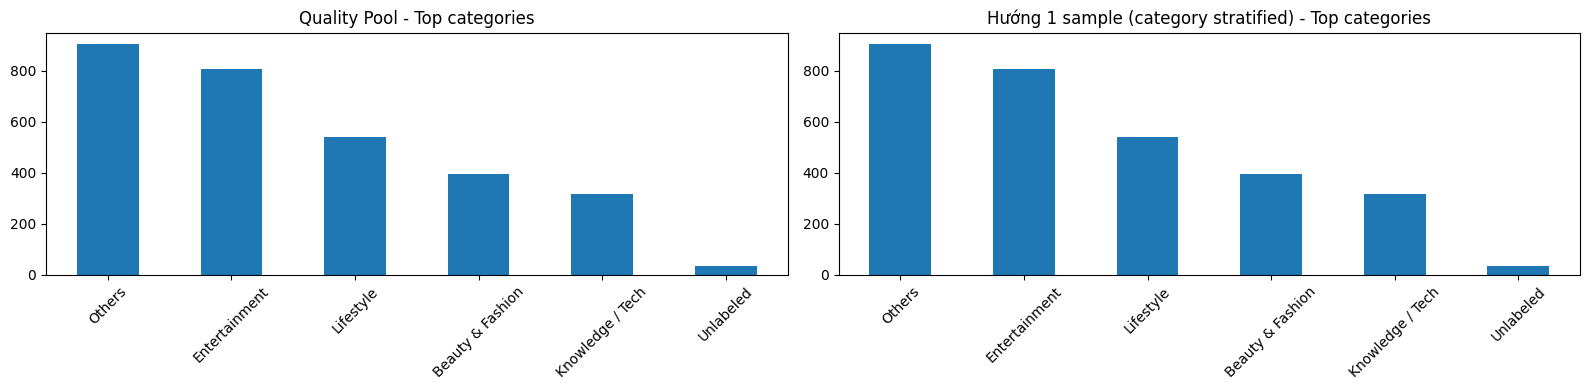

In [23]:

print("=== Hướng 1 / Size tier ===")
display(compare_distribution(quality_pool['size_tier'], quality_sample_random['size_tier']))
display(compare_distribution(quality_pool['size_tier'], quality_sample_category['size_tier']))

print("=== Hướng 1 / Primary category group ===")
display(compare_distribution(quality_pool['primary_category_group'], quality_sample_random['primary_category_group']).head(15))
display(compare_distribution(quality_pool['primary_category_group'], quality_sample_category['primary_category_group']).head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

quality_pool['primary_category_group'].value_counts().head(10).plot(kind='bar', ax=axes[0], title='Quality Pool - Top categories')
quality_sample_category['primary_category_group'].value_counts().head(10).plot(kind='bar', ax=axes[1], title='Hướng 1 sample (category stratified) - Top categories')

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



## BƯỚC 24. Hướng 2 — Stratified sampling phản ánh thị trường

Nguyên tắc triển khai đúng theo yêu cầu:

- Loại bỏ `Unlabeled`
- Giữ lại **toàn bộ MACRO**
- Lấy phần còn lại từ `MICRO` + `MID`
- Phân bổ quota theo **stratum = (`size_tier`, `primary_category_group`)**
- Quota được tính bằng **largest remainder** để tránh lỗi tổng ≠ 3000
- Có bước **cap + redistribute** để tránh lỗi quota > population


In [24]:
# ===== HƯỚNG 2: Stratified sampling phản ánh thị trường (ROBUST - 1 CELL) =====

import pandas as pd
import numpy as np

# =========================
# CONFIG
# =========================
TARGET_SAMPLE_SIZE = 3000
RANDOM_STATE = 42

# =========================
# HELPER FUNCTIONS
# =========================
def largest_remainder_allocation(weights, total):
    """
    Phân bổ quota theo tỷ trọng bằng Largest Remainder Method.
    weights: Series/array số lượng hiện có ở từng strata
    total: tổng quota cần chia
    return: pd.Series quota nguyên, tổng đúng = total
    """
    weights = pd.Series(weights).fillna(0).astype(float)
    if total < 0:
        raise ValueError("total phải >= 0")
    if weights.sum() <= 0:
        return pd.Series([0] * len(weights), index=weights.index, dtype=int)

    raw = weights / weights.sum() * total
    base = np.floor(raw).astype(int)
    remainder = raw - base
    shortfall = int(total - base.sum())

    if shortfall > 0:
        order = np.argsort(-remainder.values)
        for i in order[:shortfall]:
            base.iloc[i] += 1

    return base.astype(int)

def cap_and_redistribute_quota(quota, capacity):
    """
    Nếu quota > capacity thì cap lại, rồi redistrib phần dư cho các nhóm còn chỗ.
    Trả về quota cuối cùng, tổng giữ nguyên tối đa có thể.
    """
    quota = pd.Series(quota).copy().astype(int)
    capacity = pd.Series(capacity).copy().astype(int)

    # align index
    capacity = capacity.reindex(quota.index)
    if capacity.isnull().any():
        raise ValueError("capacity và quota không cùng index.")

    quota = quota.clip(lower=0)
    capacity = capacity.clip(lower=0)

    while True:
        overflow = (quota - capacity).clip(lower=0)
        overflow_total = int(overflow.sum())

        if overflow_total == 0:
            break

        quota = pd.concat([quota, capacity], axis=1).min(axis=1)

        available_room = (capacity - quota).clip(lower=0)
        room_total = int(available_room.sum())

        if room_total == 0:
            break

        add_back = largest_remainder_allocation(available_room, min(overflow_total, room_total))
        quota = quota + add_back

    return quota.astype(int)

def stratified_sample_by_quota(data, quota_df, stratum_cols, random_state=42):
    """
    Sample theo quota từng stratum, tránh MultiIndex, chống quota > population.
    """
    sampled_parts = []

    quota_df = quota_df.copy()
    if 'quota' not in quota_df.columns:
        raise ValueError("quota_df phải có cột 'quota'")

    for _, row in quota_df.iterrows():
        mask = pd.Series(True, index=data.index)
        for col in stratum_cols:
            mask &= (data[col] == row[col])

        subset = data.loc[mask].copy()
        q = int(row['quota'])

        if q <= 0:
            continue
        if len(subset) == 0:
            continue

        q_safe = min(q, len(subset))
        sampled = subset.sample(n=q_safe, replace=False, random_state=random_state)
        sampled_parts.append(sampled)

    if not sampled_parts:
        return data.iloc[0:0].copy().reset_index(drop=True)

    return pd.concat(sampled_parts, axis=0).reset_index(drop=True)

def assign_size_tier(f):
    """
    Rule size tier:
    <100k      -> MICRO
    100k-<1M   -> MID
    >=1M       -> MACRO
    """
    if pd.isna(f):
        return np.nan
    try:
        f = float(f)
    except:
        return np.nan

    if f < 100_000:
        return "MICRO"
    elif f < 1_000_000:
        return "MID"
    else:
        return "MACRO"

# =========================
# PRE-CHECK REQUIRED COLUMNS
# =========================
required_cols = ['creator_id', 'followers_num', 'primary_category_group']
missing_required = [c for c in required_cols if c not in df_sampling_base.columns]
if missing_required:
    raise ValueError(f"Thiếu cột bắt buộc trong df_sampling_base: {missing_required}")

# =========================
# COPY BASE
# =========================
market_base = df_sampling_base.copy()

# =========================
# CLEAN / REBUILD size_tier IF NEEDED
# =========================
if 'size_tier' not in market_base.columns:
    print("⚠️ Không thấy cột size_tier -> đang tự tạo từ followers_num")
    market_base['size_tier'] = market_base['followers_num'].apply(assign_size_tier)
else:
    # chuẩn hóa text trước
    market_base['size_tier'] = (
        market_base['size_tier']
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({'NAN': np.nan, 'NONE': np.nan, '': np.nan})
    )

    valid_tiers = {'MICRO', 'MID', 'MACRO'}
    actual_tiers = set(market_base['size_tier'].dropna().unique())

    # nếu không có tier hợp lệ nào thì tạo lại toàn bộ
    if len(actual_tiers.intersection(valid_tiers)) == 0:
        print("⚠️ size_tier hiện tại không hợp lệ -> đang tạo lại từ followers_num")
        market_base['size_tier'] = market_base['followers_num'].apply(assign_size_tier)
    else:
        # chỉ fill lại những dòng tier lỗi / missing
        invalid_mask = ~market_base['size_tier'].isin(['MICRO', 'MID', 'MACRO'])
        if invalid_mask.any():
            print(f"⚠️ Có {invalid_mask.sum():,} dòng size_tier lỗi/missing -> đang sửa từ followers_num")
            market_base.loc[invalid_mask, 'size_tier'] = market_base.loc[invalid_mask, 'followers_num'].apply(assign_size_tier)

# validate lại
market_base['size_tier'] = (
    market_base['size_tier']
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({'NAN': np.nan, 'NONE': np.nan, '': np.nan})
)

print("Phân phối size_tier sau chuẩn hóa:")
display(market_base['size_tier'].value_counts(dropna=False).to_frame('n'))

if market_base['size_tier'].dropna().isin(['MICRO', 'MID', 'MACRO']).sum() == 0:
    raise ValueError("size_tier vẫn không hợp lệ sau khi rebuild. Hãy kiểm tra followers_num.")

# =========================
# CLEAN primary_category_group
# =========================
market_base['primary_category_group'] = (
    market_base['primary_category_group']
    .astype(str)
    .str.strip()
    .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
)

# bỏ Unlabeled và null category
market_base = market_base[
    market_base['primary_category_group'].notna() &
    (market_base['primary_category_group'] != 'Unlabeled')
].copy().reset_index(drop=True)

print(f"Số creators sau khi bỏ Unlabeled/null category: {len(market_base):,}")
display(market_base['primary_category_group'].value_counts().head(15).to_frame('n'))

# =========================
# SPLIT MACRO vs NON-MACRO
# =========================
macro_all = market_base[market_base['size_tier'] == 'MACRO'].copy().reset_index(drop=True)
non_macro = market_base[market_base['size_tier'].isin(['MICRO', 'MID'])].copy().reset_index(drop=True)

macro_count = len(macro_all)
remaining_slots = TARGET_SAMPLE_SIZE - macro_count

print(f"Số MACRO giữ lại toàn bộ: {macro_count:,}")
print(f"Số MICRO + MID available: {len(non_macro):,}")
print(f"Số slot còn lại cho MICRO + MID: {remaining_slots:,}")

if remaining_slots < 0:
    raise ValueError(
        f"Số MACRO ({macro_count}) đã vượt TARGET_SAMPLE_SIZE ({TARGET_SAMPLE_SIZE}). "
        "Bạn cần tăng sample size hoặc thay đổi rule."
    )

if len(non_macro) < remaining_slots:
    raise ValueError(
        f"MICRO + MID chỉ có {len(non_macro):,} rows, không đủ lấp {remaining_slots:,} slot."
    )

# =========================
# BUILD STRATUM COUNTS
# =========================
stratum_counts = (
    non_macro
    .groupby(['size_tier', 'primary_category_group'], dropna=False)
    .size()
    .rename('available')
    .reset_index()
)

if len(stratum_counts) == 0:
    raise ValueError("Không có strata nào trong non_macro. Kiểm tra lại size_tier / primary_category_group.")

display(stratum_counts.sort_values('available', ascending=False).head(20))

# =========================
# ALLOCATE QUOTA
# =========================
quota_raw = largest_remainder_allocation(stratum_counts['available'], remaining_slots)
stratum_counts['quota_raw'] = quota_raw.values

quota_safe = cap_and_redistribute_quota(
    quota=stratum_counts.set_index(['size_tier', 'primary_category_group'])['quota_raw'],
    capacity=stratum_counts.set_index(['size_tier', 'primary_category_group'])['available']
)

quota_safe_df = quota_safe.rename('quota').reset_index()

print("Tổng quota non_macro ban đầu:", int(stratum_counts['quota_raw'].sum()))
print("Tổng quota non_macro sau cap+redistribute:", int(quota_safe_df['quota'].sum()))
display(quota_safe_df.sort_values('quota', ascending=False).head(20))

if int(quota_safe_df['quota'].sum()) != remaining_slots:
    raise ValueError(
        f"Tổng quota sau cap+redistribute = {int(quota_safe_df['quota'].sum())}, "
        f"không khớp remaining_slots = {remaining_slots}"
    )

# =========================
# SAMPLE NON-MACRO
# =========================
market_non_macro_sample = stratified_sample_by_quota(
    data=non_macro,
    quota_df=quota_safe_df,
    stratum_cols=['size_tier', 'primary_category_group'],
    random_state=RANDOM_STATE
)

# =========================
# CONCAT FINAL
# =========================
market_sample = (
    pd.concat([macro_all, market_non_macro_sample], axis=0)
    .drop_duplicates(subset='creator_id')
    .reset_index(drop=True)
)

print(f"market_non_macro_sample: {len(market_non_macro_sample):,}")
print(f"market_sample cuối cùng trước vá: {len(market_sample):,}")

# =========================
# PATCH IF ROUNDING / DEDUP CAUSED GAP
# =========================
if len(market_sample) != TARGET_SAMPLE_SIZE:
    print("⚠️ Cảnh báo: sample cuối chưa đúng 3000. Đang vá bằng sampling bổ sung từ pool còn lại...")

    sampled_ids = set(market_sample['creator_id'].astype(str))
    remaining_pool = market_base[~market_base['creator_id'].astype(str).isin(sampled_ids)].copy().reset_index(drop=True)

    gap = TARGET_SAMPLE_SIZE - len(market_sample)

    if gap > 0:
        if len(remaining_pool) < gap:
            raise ValueError(
                f"Không đủ dữ liệu để vá sample. Cần thêm {gap}, nhưng remaining_pool chỉ có {len(remaining_pool)}."
            )
        filler = remaining_pool.sample(n=gap, random_state=RANDOM_STATE, replace=False)
        market_sample = (
            pd.concat([market_sample, filler], axis=0)
            .drop_duplicates(subset='creator_id')
            .reset_index(drop=True)
        )

    elif gap < 0:
        # trường hợp hiếm: nếu dư vì logic nào đó thì cắt bớt ngẫu nhiên nhưng reproducible
        market_sample = market_sample.sample(n=TARGET_SAMPLE_SIZE, random_state=RANDOM_STATE, replace=False).reset_index(drop=True)

print(f"market_sample sau bước vá: {len(market_sample):,}")

if len(market_sample) != TARGET_SAMPLE_SIZE:
    raise ValueError(f"market_sample cuối cùng vẫn không đúng {TARGET_SAMPLE_SIZE}. Hiện tại: {len(market_sample)}")

# =========================
# FINAL VALIDATION
# =========================
print("\n===== VALIDATION CUỐI =====")
print("Số creator_id unique:", market_sample['creator_id'].nunique())
print("Số dòng:", len(market_sample))
print("\nPhân phối size_tier:")
display(market_sample['size_tier'].value_counts(dropna=False).to_frame('n'))
print("\nPhân phối primary_category_group:")
display(market_sample['primary_category_group'].value_counts(dropna=False).to_frame('n'))

# nếu muốn xem cross-tab
print("\nCross-tab size_tier x primary_category_group:")
display(pd.crosstab(market_sample['size_tier'], market_sample['primary_category_group']))

# market_sample là output cuối cùng của bước 24

Phân phối size_tier sau chuẩn hóa:


,n
size_tier,
MICRO,2457
MID,428
MACRO,115


Số creators sau khi bỏ Unlabeled/null category: 2,965


,n
primary_category_group,
Others,904
Entertainment,808
Lifestyle,542
Beauty & Fashion,395
Knowledge / Tech,316


Số MACRO giữ lại toàn bộ: 114
Số MICRO + MID available: 2,851
Số slot còn lại cho MICRO + MID: 2,886


ValueError: MICRO + MID chỉ có 2,851 rows, không đủ lấp 2,886 slot.


## BƯỚC 25. Đánh giá nhanh Hướng 2

So sánh phân phối giữa:
- `market_base` (sau khi bỏ `Unlabeled`)
- `market_sample` 3000 IDs


=== Hướng 2 / Size tier ===


,source,sample,diff_pct_point
size_tier,,,
MICRO,0.858864,0.803667,-5.519736
MID,0.113901,0.106667,-0.723432
MACRO,0.027235,0.089667,6.243168


=== Hướng 2 / Primary category group ===


,source,sample,diff_pct_point
primary_category_group,,,
Others,0.292700,0.306000,1.329979
Entertainment,0.272957,0.266667,-0.629071
Lifestyle,0.190442,0.187333,-0.310911
Beauty & Fashion,0.147514,0.145000,-0.251443
Knowledge / Tech,0.096386,0.095000,-0.138554


=== Hướng 2 / Stratum (size_tier x primary_category_group) ===


,source,sample,diff_pct_point
MICRO | Entertainment,0.245925,0.230000,-1.592488
MICRO | Others,0.237420,0.222333,-1.508694
MICRO | Lifestyle,0.165536,0.155000,-1.053609
MICRO | Beauty & Fashion,0.127265,0.119000,-0.826536
MICRO | Knowledge / Tech,0.082717,0.077333,-0.538409
MID | Others,0.041713,0.039000,-0.271307
MID | Entertainment,0.022274,0.021000,-0.127397
MID | Lifestyle,0.021059,0.019667,-0.139236
MID | Beauty & Fashion,0.017212,0.016000,-0.121170
MACRO | Others,0.013567,0.044667,3.109979


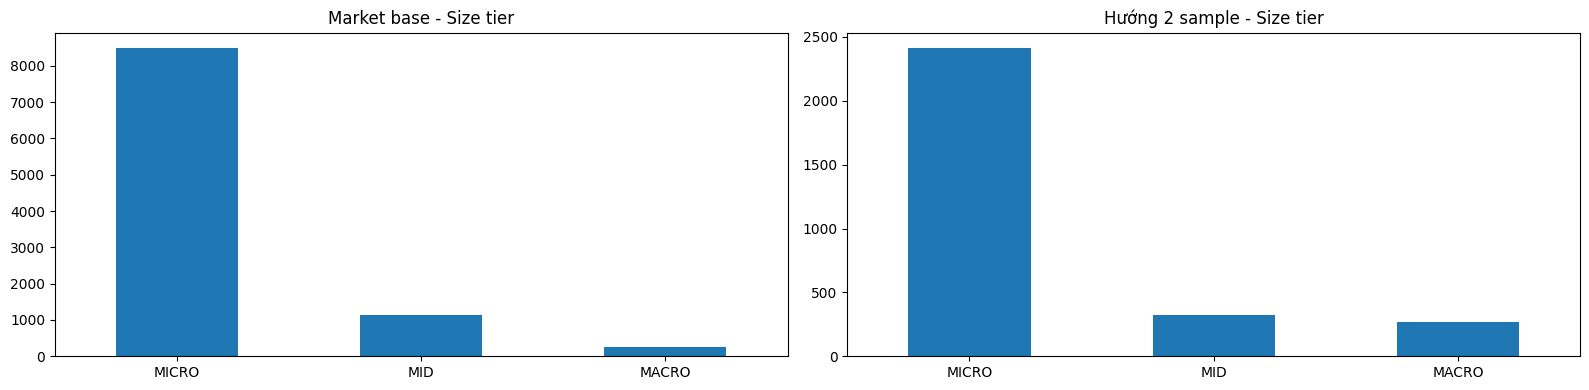

In [ ]:

print("=== Hướng 2 / Size tier ===")
display(compare_distribution(market_base['size_tier'], market_sample['size_tier']))

print("=== Hướng 2 / Primary category group ===")
display(compare_distribution(market_base['primary_category_group'], market_sample['primary_category_group']).head(15))

print("=== Hướng 2 / Stratum (size_tier x primary_category_group) ===")
market_base_stratum = market_base['size_tier'].astype(str) + ' | ' + market_base['primary_category_group'].astype(str)
market_sample_stratum = market_sample['size_tier'].astype(str) + ' | ' + market_sample['primary_category_group'].astype(str)
display(compare_distribution(market_base_stratum, market_sample_stratum).head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
market_base['size_tier'].value_counts().plot(kind='bar', ax=axes[0], title='Market base - Size tier')
market_sample['size_tier'].value_counts().plot(kind='bar', ax=axes[1], title='Hướng 2 sample - Size tier')
for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()



## BƯỚC 26. Lưu 2 hướng sampling

Xuất ra:
- `sample_direction1_random.csv`
- `sample_direction1_category_stratified.csv`
- `sample_direction2_market_reflective.csv`

Ngoài ra còn xuất file chỉ chứa `creator_id` để tiện đưa vào crawler / pipeline kế tiếp.


In [ ]:
from pymongo import MongoClient
import json

# Kết nối MongoDB
client = MongoClient("mongodb://localhost:27017/")  # chỉnh URI nếu khác
db = client["tiktok_ads_db"]

# Map dataframe → tên collection
samples = {
    "sample_direction1_random":             quality_sample_random,
    "sample_direction1_category_stratified": quality_sample_category,
    "sample_direction2_market_reflective":   market_sample,
}

for col_name, df in samples.items():
    collection = db[col_name]
    collection.drop()  # xóa cũ nếu chạy lại
    records = json.loads(df.to_json(orient="records", force_ascii=False))
    collection.insert_many(records)
    print(f"✓ [{col_name}] — đã insert {len(records)} documents")

print("\nĐã lưu xong tất cả sample vào MongoDB tiktok_ads_db.")

✓ [sample_direction1_random] — đã insert 3000 documents
✓ [sample_direction1_category_stratified] — đã insert 3000 documents
✓ [sample_direction2_market_reflective] — đã insert 3000 documents

Đã lưu xong tất cả sample vào MongoDB tiktok_ads_db.



## BƯỚC 27. Kết luận sử dụng

### Khi nào dùng Hướng 1
Dùng khi mục tiêu là:
- build baseline clustering ổn định
- giảm méo cụm do missing value
- so sánh mô hình KMeans / GMM / HDBSCAN trên tập numeric sạch hơn

### Khi nào dùng Hướng 2
Dùng khi mục tiêu là:
- phản ánh cấu trúc thị trường thật
- giữ `MACRO` đầy đủ
- dùng sample 3000 như một mini-market

### Khuyến nghị thực tế cho đề tài
- **Chạy cả hai hướng**
- So sánh độ ổn định cụm và chất lượng metric nội bộ  
  (`silhouette`, `davies_bouldin`, phân bố cluster size)
- Nếu Hướng 1 cho cụm rõ ràng hơn, đó là tín hiệu mạnh rằng **missing value ở dữ liệu gốc đang gây méo clustering**


In [ ]:
# Chia làm 3 file JSON để dễ upload lên MongoDB  mỗi file ~1000 records

import json
import math

# Đọc file gốc
with open("C:\\Users\\Admin\\Desktop\\TANPHAT\\Dự án_canhan\\TIKTOK_V2\\tiktok_ads_db.sample_direction1_category_stratified.json", encoding="utf-8") as f:
    data = json.load(f)

total = len(data)          # 3000
chunk = math.ceil(total / 3)  # 1000 mỗi phần

parts = {
    "part1": data[0:chunk],
    "part2": data[chunk:chunk*2],
    "part3": data[chunk*2:],
}

for name, records in parts.items():
    filename = f"sample_direction1_category_stratified_{name}.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print(f"✓ {filename} — {len(records)} records")


✓ sample_direction1_category_stratified_part1.json — 1000 records
✓ sample_direction1_category_stratified_part2.json — 1000 records
✓ sample_direction1_category_stratified_part3.json — 1000 records
